#**upload data**

In [ ]:
import pandas as pd
data = pd.read_csv("/content/archive.zip")

In [ ]:
data.head(30)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


#**(Exploratory Data Analysis - EDA)**

ROW & COLUMNS

In [ ]:
data.shape

(8807, 12)

COLUMN NAMES

In [ ]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

DATA TYPE

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


CHECK MISSING VALUES

In [ ]:
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


BASIC STATISTICS

In [ ]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


#**Data cleaning**

MISSING VALUES FILL

In [ ]:
data.fillna(0, inplace=True)

DUPLICATE REMOVE

In [ ]:
data.drop_duplicates(inplace=True)

COLUMN RENAME

In [ ]:
data.rename(columns={
    "show_id": "Show_ID",
    "type": "Content_Type",
    "release_year": "Year",
    "listed_in": "Genre"
}, inplace=True)
print(data.columns)

Index(['Show_ID', 'Content_Type', 'title', 'director', 'cast', 'country',
       'date_added', 'Year', 'rating', 'duration', 'Genre', 'description'],
      dtype='object')


REMOVE OUTLIERS

In [ ]:
Q1 = data["Year"].quantile(0.25)
Q3 = data["Year"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

data = data[(data["Year"] >= lower_limit) & (data["Year"] <= upper_limit)]
print(data.shape)
data.describe()

(7624, 12)


,Year
count,7624.000000
mean,2016.912775
std,2.942338
min,2009.000000
25%,2015.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


#**Visualization**

In [ ]:
import matplotlib.pyplot as plt

LINE PLOT

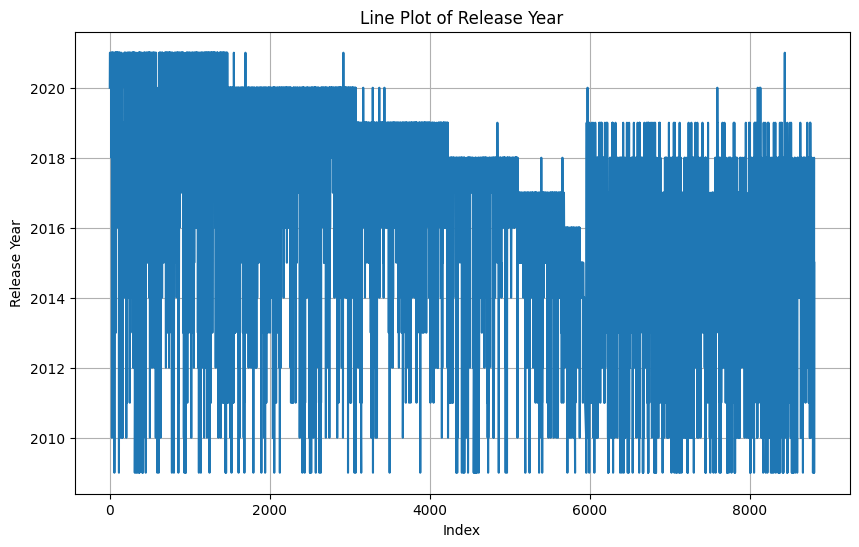

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(data['Year'])
plt.xlabel('Index')
plt.ylabel('Release Year')
plt.title('Line Plot of Release Year')
plt.grid(True)
plt.show()

BAR CHART

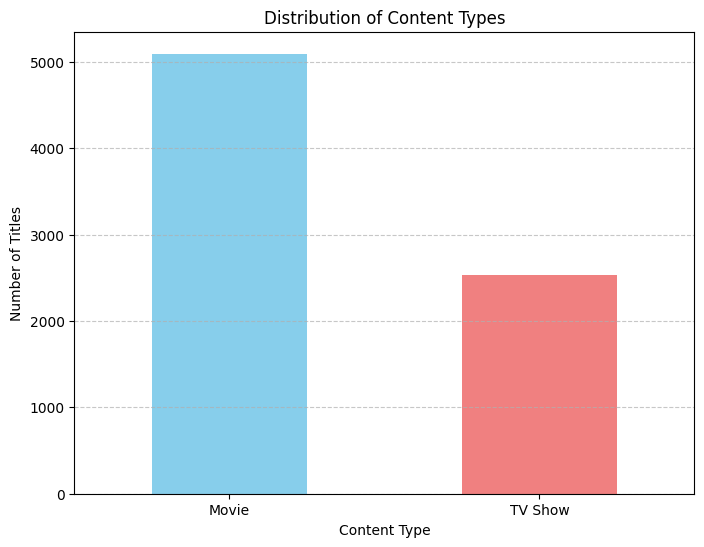

In [ ]:
plt.figure(figsize=(8, 6))
data['Content_Type'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of Content Types')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

HISTOGRAM

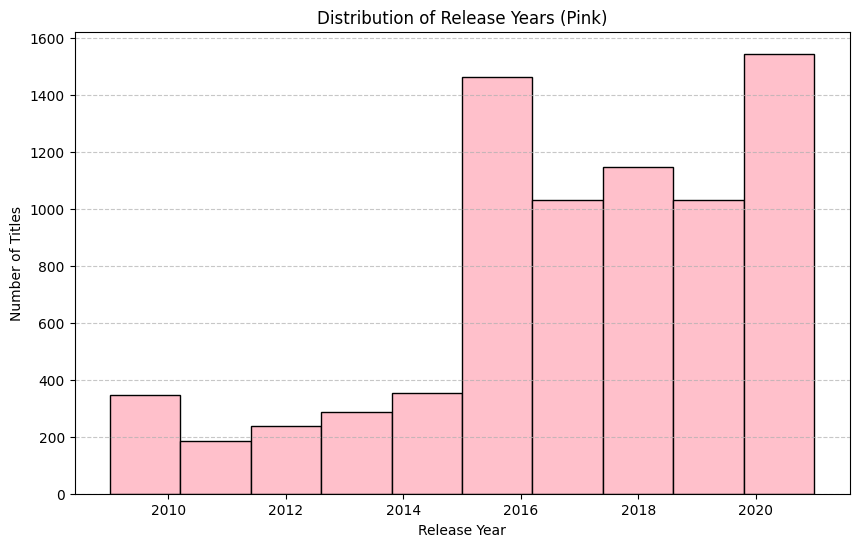

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data['Year'], bins=10, edgecolor='black', color='pink')
plt.title('Distribution of Release Years (Pink)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

SCATTER PLOT

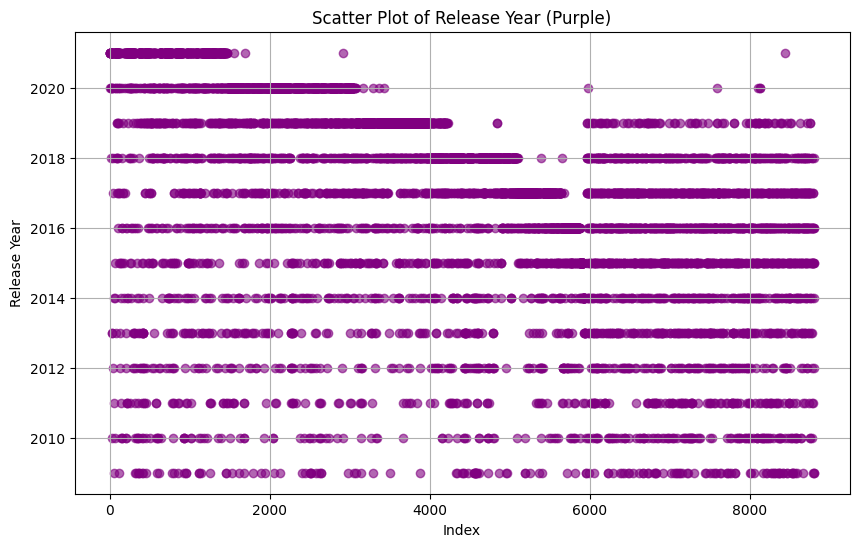

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(data.index, data['Year'], color='purple', alpha=0.6)
plt.title('Scatter Plot of Release Year (Purple)')
plt.xlabel('Index')
plt.ylabel('Release Year')
plt.grid(True)
plt.show()

HEATMAP

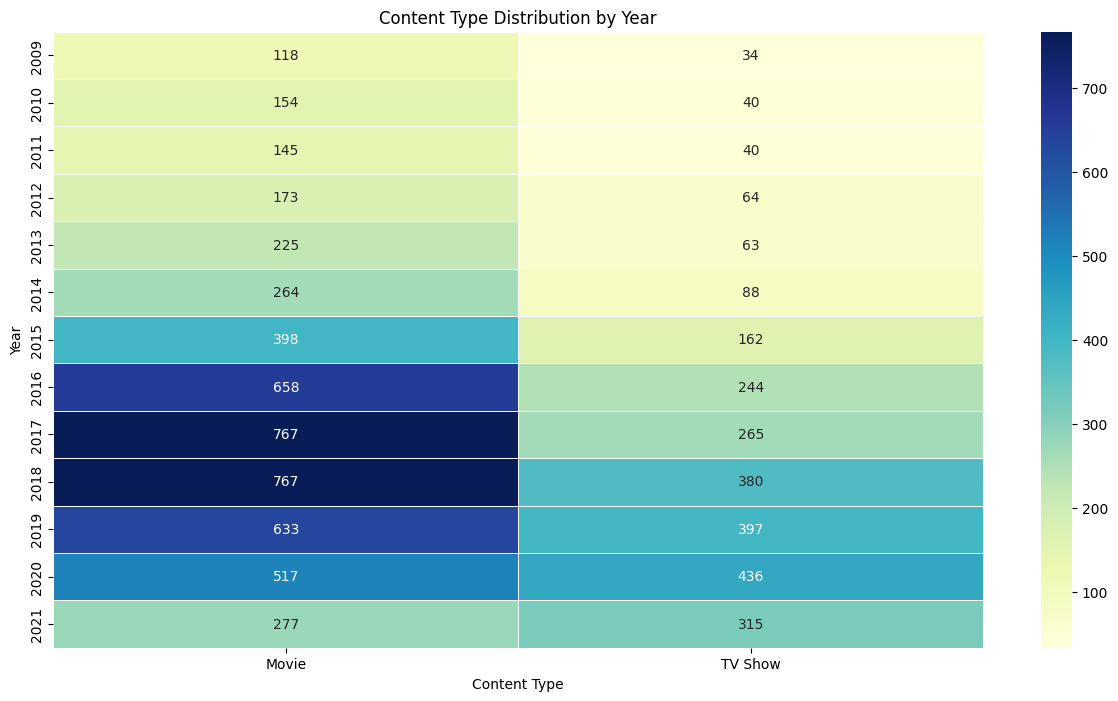

In [ ]:
import seaborn as sns

heatmap_data = data.groupby(['Year', 'Content_Type']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5)
plt.title('Content Type Distribution by Year')
plt.xlabel('Content Type')
plt.ylabel('Year')
plt.show()

#**Inferential Statistics**

In [ ]:
from scipy.stats import ttest_ind

movies = data[data["Content_Type"] == "Movie"]["Year"]
tvshows = data[data["Content_Type"] == "TV Show"]["Year"]

t_stat, p_value = ttest_ind(movies, tvshows)

print("T-Statistic:", t_stat)
print("P-value:", p_value)

T-Statistic: -14.813060160717686
P-value: 5.761649592013926e-49


#**Hypothesis Testing**

In [ ]:
from scipy.stats import ttest_ind

movies = data[data["Content_Type"] == "Movie"]["Year"].dropna()
tvshows = data[data["Content_Type"] == "TV Show"]["Year"].dropna()

t_stat, p_value = ttest_ind(movies, tvshows, equal_var=False)

print("T-Statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

print("\nHypothesis Testing Result:")

if p_value < alpha:
    print("Reject H0")
    print("Conclusion: Movies aur TV Shows ke average year me significant difference hai.")
else:
    print("Fail to Reject H0")
    print("Conclusion: Dono ka average year me koi significant difference nahi hai.")


T-Statistic: -2.5000000000001137
P-value: 0.08244173716173887

Hypothesis Testing Result:
Fail to Reject H0
Conclusion: Dono ka average year me koi significant difference nahi hai.


#**Confidance interval**

In [ ]:
import numpy as np
import scipy.stats as stats

mean = np.mean(data["Year"])
sem = stats.sem(data["Year"])

confidence_interval = stats.t.interval(
    0.95, len(data["Year"]) - 1, loc=mean, scale=sem
)

print("Mean:", mean)
print("95% Confidence Interval:", confidence_interval)

Mean: 2016.91277544596
95% Confidence Interval: (np.float64(2016.8467185516408), np.float64(2016.9788323402793))


#**Correlation**

In [ ]:
corr, p_value = (data["Year"], data["duration"])

print("Correlation:", corr)
print("P-value:", p_value)


Correlation: 0       2020
1       2021
2       2021
3       2021
4       2021
        ... 
8800    2012
8801    2015
8803    2018
8804    2009
8806    2015
Name: Year, Length: 7624, dtype: int64
P-value: 0          90 min
1       2 Seasons
2        1 Season
3        1 Season
4       2 Seasons
          ...    
8800     1 Season
8801       96 min
8803    2 Seasons
8804       88 min
8806      111 min
Name: duration, Length: 7624, dtype: object


#**Covariance**

In [ ]:
import numpy as np

movies = data[data["Content_Type"] == "Movie"]["Year"].dropna()
tvshows = data[data["Content_Type"] == "TV Show"]["Year"].dropna()

min_len = min(len(movies), len(tvshows))

movies = movies[:min_len]
tvshows = tvshows[:min_len]

cov_matrix = np.cov(movies, tvshows)

cov_value = cov_matrix[0, 1]

print("Covariance:", cov_value)


Covariance: 0.5
